# Lab 28 — OFDM as a System: Channel Estimation, ICI, Coding, PAPR, Spectrum, DMT and Radar

**Companion to Chapter 17** (*OFDM and Multicarrier*). Lab 7 builds the OFDM link itself (IFFT, cyclic prefix, one-tap
equaliser, Schmidl–Cox, PAPR); this lab takes the system view.
**Time needed:** about 2 hours. **Difficulty:** advanced.

OFDM won because it turns a frequency-selective channel into hundreds of flat ones. Making a real OFDM system work is a series of
engineering trades around that idea: estimating hundreds of channel coefficients from a few pilots, keeping the subcarriers
orthogonal when oscillators drift and users move, recovering the frequency diversity that one-tap equalisation hides, taming a
waveform whose peaks are 10 dB above its average, keeping its spectrum out of the neighbours' channels, and, on wires, loading bits
tone by tone. The same waveform even doubles as a radar. Each section below reproduces one of Chapter 17's experiments with the code
that drew its figure (`commlib/ofdmadv.py`, built on `commlib/ofdm.py`), and then lets you push on it.

### What you will learn
1. Compare LS + interpolation, DFT-based and LMMSE channel estimators, and choose a pilot spacing.
2. Measure inter-carrier interference from frequency offset, Doppler and phase noise, and remove the common phase error.
3. See how coding plus bit interleaving (BICM) turns frequency-selective fading into diversity.
4. Reduce PAPR by iterative clipping and filtering, and trade back-off, EVM and ACLR through a PA.
5. Contain the spectrum with WOLA windowing and filtered OFDM.
6. Load bits on a DSL line (DMT) and see the rate-versus-reach curve.
7. Turn the OFDM grid into a range–Doppler radar map.

### Prerequisites
Lab 7 (OFDM basics), Lab 5 (TDL channels, Doppler), Lab 8 (Viterbi). Chapter 17.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Channel estimation: LS, DFT, LMMSE | yes |
| 2 | ICI: frequency offset, Doppler, phase noise and the CPE | yes |
| 3 | Coded OFDM and frequency diversity | |
| 4 | PAPR, clipping and filtering, and the power amplifier | yes |
| 5 | Spectral containment: WOLA and filtered OFDM | yes |
| 6 | DMT on copper: bit loading and reach | yes |
| 7 | OFDM as a radar | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import ofdm as co
from commlib import ofdmadv as oa
from commlib import labkit as lk

rng = lk.setup(seed=28, lab="28")
QPSK, Q16, Q64 = (cl.get_constellation(n) for n in ("qpsk", "16qam", "64qam"))
qam = lambda c, n: c.modulate(cl.random_bits(c.k * n, rng))

Lab 28 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 28


## 1. Channel estimation: LS, DFT, LMMSE

Pilots of known value give least-squares (LS) estimates $\hat H_p = Y_p/X_p$ at a subset of subcarriers. Three ways to fill in the rest:
**linear interpolation** (simple, biased where the channel curves); **DFT-based** (fit a short impulse response to the pilots, which removes
the noise outside the CP-length delay window); **LMMSE** ($\hat{\mathbf H} = \mathbf R_{hp}(\mathbf R_{pp}+N_0\mathbf I)^{-1}\hat{\mathbf H}_p$, using
the channel's frequency correlation from its power-delay profile). Sampling theory sets the pilot spacing: $D_f \le 1/(\tau_{\max}\Delta f)$.
The setting is Chapter 17's: LTE 10 MHz (1024-point FFT, 600 subcarriers, 15 kHz), pilots every 6th subcarrier, EVA channel.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

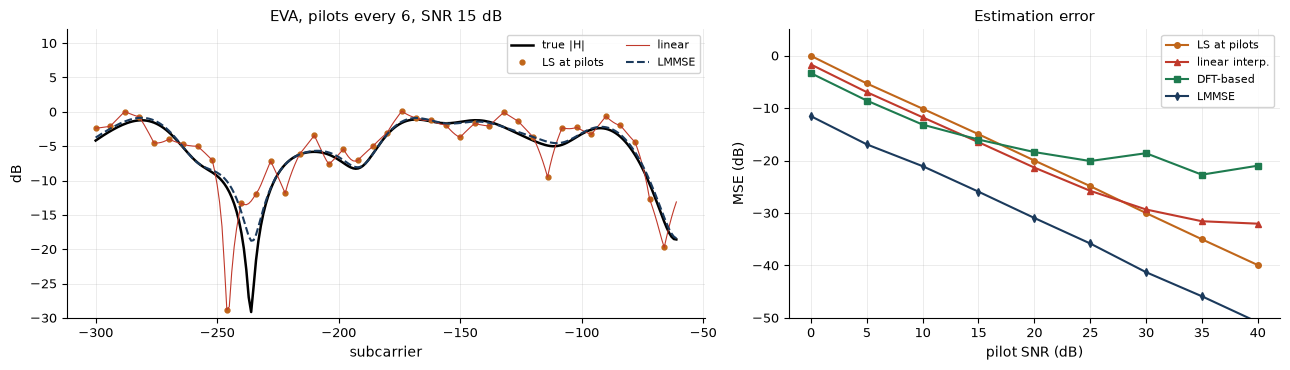

,
max excess delay,2.60 us
Nyquist pilot spacing 1/(tau_max df),25.6 subcarriers
your spacing,6
LMMSE MSE at 20 dB,-30.9 dB
linear MSE at 20 dB,-21.3 dB


In [3]:
N, Nu = 1024, 600
cfg = co.OFDMConfig(N, Nu, 72)
k = cfg.k.astype(float)

def chest_demo(profile="EVA", Dp=6, snr_view=15):
    d, p = oa.tdl_pdp(profile, oa.FS_LTE)
    pidx = np.arange(0, Nu, Dp); kp = k[pidx]
    W_cache = {}
    snrs = np.arange(0, 41, 5)
    mse = {n: [] for n in ["LS at pilots", "linear interp.", "DFT-based", "LMMSE"]}
    for snr in snrs:
        n0 = lk.undb(-snr)
        W = oa.lmmse_weights(kp, k, n0, d, p, N)
        acc = np.zeros(4)
        H = oa.tdl_freq_response(profile, k, N, oa.FS_LTE, rng, n_draws=30)
        for t in range(30):
            Hls = H[t] + np.sqrt(n0 / 2) * (rng.standard_normal(Nu) + 1j * rng.standard_normal(Nu))
            Hp = Hls[pidx]
            est = (oa.chest_ls_interp(Hp, kp, k), oa.chest_dft(Hp, kp, k, N, 72), W @ Hp)
            acc += [np.mean(np.abs(Hp - H[t][pidx]) ** 2)] + [np.mean(np.abs(e - H[t]) ** 2) for e in est]
            if snr == snr_view and t == 0:
                ex = (H[t], Hp) + est
        for i, nme in enumerate(mse):
            mse[nme].append(lk.db(acc[i] / 30))
    f, ax = lk.fig((13, 3.8), 1, 2, gridspec_kw=dict(width_ratios=[1.3, 1]))
    Ht, Hp, Hl, Hd, Hm = ex
    sel = slice(0, 240); msk = pidx < 240
    ax[0].plot(k[sel], lk.db(np.abs(Ht[sel]) ** 2), "k", lw=1.8, label="true |H|")
    ax[0].plot(kp[msk], lk.db(np.abs(Hp[msk]) ** 2), "o", color=lk.ORANGE, ms=3.5, label="LS at pilots")
    ax[0].plot(k[sel], lk.db(np.abs(Hl[sel]) ** 2), color=lk.RED, lw=0.8, label="linear")
    ax[0].plot(k[sel], lk.db(np.abs(Hm[sel]) ** 2), "--", color=lk.NAVY, label="LMMSE")
    ax[0].set_ylim(-30, 12); ax[0].set_xlabel("subcarrier"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8, ncol=2)
    ax[0].set_title(f"{profile}, pilots every {Dp}, SNR {snr_view} dB")
    for (nme, v), col, mk in zip(mse.items(), [lk.ORANGE, lk.RED, lk.GREEN, lk.NAVY], "o^sd"):
        ax[1].plot(snrs, v, marker=mk, color=col, ms=4, label=nme)
    ax[1].set_xlabel("pilot SNR (dB)"); ax[1].set_ylabel("MSE (dB)"); ax[1].legend(fontsize=8); ax[1].set_ylim(-50, 5)
    ax[1].set_title("Estimation error")
    lk.show(f)
    dmax = (d.max() + 1) / oa.FS_LTE
    lk.table([["max excess delay", f"{dmax * 1e6:.2f} us"], ["Nyquist pilot spacing 1/(tau_max df)", f"{1 / (dmax * 15e3):.1f} subcarriers"],
              ["your spacing", Dp], ["LMMSE MSE at 20 dB", f"{mse['LMMSE'][4]:.1f} dB"], ["linear MSE at 20 dB", f"{mse['linear interp.'][4]:.1f} dB"]], ["", ""])

lk.interact(chest_demo, profile=lk.choice(["EPA", "EVA", "ETU"], "EVA", "channel"), Dp=lk.choice([2, 3, 4, 6, 8, 12], 6, "pilot spacing"),
            snr_view=lk.choice([0, 5, 10, 15, 20, 25, 30], 15, "SNR shown on the left (dB)"))

**What you should see.** LMMSE is best everywhere, roughly 10 dB below the raw pilot noise at moderate SNR (about −31 dB at 20 dB SNR against
−21 dB for linear interpolation), because it averages many pilots using the channel's known correlation. Linear interpolation floors at high SNR (its bias, not noise, dominates in EVA); the DFT estimator
tracks LMMSE closely at moderate SNR but floors too, because EVA's paths do not fall on its delay grid (the leakage pitfall in Chapter 17).
Switch to ETU (5 µs delay): with $D_p = 12$ the pilot spacing exceeds the Nyquist limit of about 13 and every estimator fails.

### Try it yourself 1.1
NR at 30 kHz with 3 µs of excess delay: what is the largest pilot spacing $D_f$ (subcarriers) allowed by $D_f \le 1/(\tau_{\max}\Delta f)$?

In [5]:
answer_1_1 = None
lk.check("1.1 max pilot spacing, 3 us, 30 kHz", answer_1_1, 1 / (3e-6 * 30e3), atol=0.2)

[TODO] 1.1 max pilot spacing, 3 us, 30 kHz: not attempted yet: replace the None with your answer

## 2. ICI: frequency offset, Doppler and phase noise

A frequency offset of $\epsilon$ subcarrier spacings rotates and attenuates every subcarrier by $\mathrm{sinc}(\epsilon)$ and leaks the rest into its
neighbours: $\mathrm{SIR} = \mathrm{sinc}^2\epsilon/(1-\mathrm{sinc}^2\epsilon) \approx 3/(\pi\epsilon)^2$. Doppler spread does the same with
$\mathrm{SIR}\approx 6/(\pi f_DT)^2$. Oscillator **phase noise** has two parts: a **common phase error** (CPE) that rotates the whole symbol and is easily
removed with pilots, and a residual ICI $\approx \pi\beta T/3$ (Wiener phase noise of linewidth $\beta$) that is not.

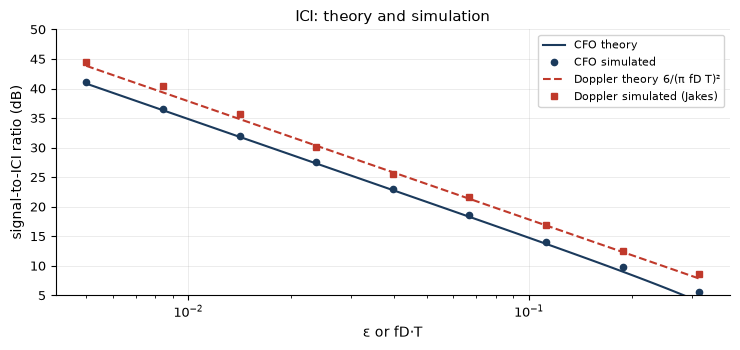

Chapter 17 frequency-error budget,
"28 GHz, 0.1 ppm, 120 kHz SCS: CFO SIR",27.5 dB
"28 GHz, 30 km/h, 120 kHz: Doppler SIR",41.6 dB
same offset at 15 kHz SCS: CFO SIR,9.1 dB


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

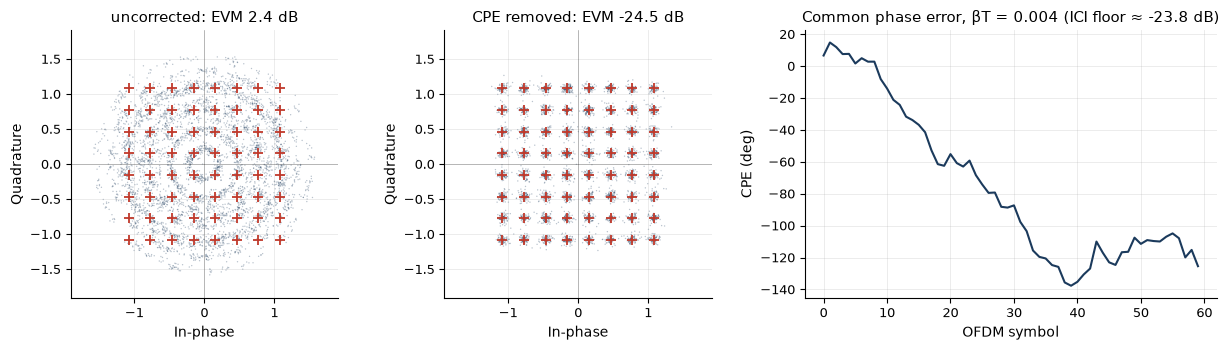

In [7]:
cfg_i = co.OFDMConfig(256, 200, 0)
g = qam(Q16, 200 * 40).reshape(40, 200)
x = co.ofdm_modulate(g, cfg_i)
eps_list = np.logspace(-2.3, -0.5, 9)
sir_c, sir_d = [], []
for e in eps_list:
    Y = co.ofdm_demodulate(cl.apply_cfo(x, e / 256), cfg_i)
    corr = np.sum(Y * np.conj(g), axis=1, keepdims=True) / np.sum(np.abs(g) ** 2, axis=1, keepdims=True)
    sir_c.append(lk.db(np.mean(np.abs(g) ** 2) / np.mean(np.abs(Y - corr * g) ** 2)))
    num = den = 0.0
    for _ in range(20):
        h = cl.jakes_process(len(x), e / 256, n_sin=24, rng=rng)
        Yd = co.ofdm_demodulate(x * h, cfg_i)
        hb = h.reshape(-1, 256).mean(axis=1, keepdims=True)
        num += np.mean(np.abs(Yd - hb * g) ** 2); den += np.mean(np.abs(h) ** 2) * np.mean(np.abs(g) ** 2)
    sir_d.append(lk.db(den / num))
ef = np.logspace(-2.3, -0.5, 100)
f, ax = lk.fig((7.5, 3.6))
ax.semilogx(ef, oa.sir_cfo_db(ef), color=lk.NAVY, label="CFO theory"); ax.semilogx(eps_list, sir_c, "o", color=lk.NAVY, label="CFO simulated")
ax.semilogx(ef, oa.sir_doppler_db(ef), "--", color=lk.RED, label="Doppler theory 6/(π fD T)²")
ax.semilogx(eps_list, sir_d, "s", color=lk.RED, label="Doppler simulated (Jakes)")
ax.set_xlabel("ε or fD·T"); ax.set_ylabel("signal-to-ICI ratio (dB)"); ax.legend(fontsize=8); ax.set_ylim(5, 50)
ax.set_title("ICI: theory and simulation")
lk.show(f)
lk.table([["28 GHz, 0.1 ppm, 120 kHz SCS: CFO SIR", f"{oa.sir_cfo_db(0.1e-6 * 28e9 / 120e3):.1f} dB"],
          ["28 GHz, 30 km/h, 120 kHz: Doppler SIR", f"{oa.sir_doppler_db(30 / 3.6 * 28e9 / 3e8 / 120e3):.1f} dB"],
          ["same offset at 15 kHz SCS: CFO SIR", f"{oa.sir_cfo_db(0.1e-6 * 28e9 / 15e3):.1f} dB"]], ["Chapter 17 frequency-error budget", ""])

def pn_demo(beta_T=0.004, constellation="64qam"):
    con = cl.get_constellation(constellation)
    cfg_p = co.OFDMConfig(256, 200, 16)
    gg = qam(con, 200 * 60).reshape(60, 200)
    xx = co.ofdm_modulate(gg, cfg_p)
    pn = cl.phase_noise(len(xx), beta_T / 256, rng=rng)
    Y = co.ofdm_demodulate(xx * pn, cfg_p)
    pil = np.zeros_like(gg); pil[:, ::12] = gg[:, ::12]                 # every 12th subcarrier is a known pilot
    Yc, cpe = oa.cpe_correct(Y, pil)
    f, ax = lk.fig((12.5, 3.6), 1, 3, gridspec_kw=dict(width_ratios=[1, 1, 1.4]))
    lk.constellation(ax[0], Y, con.points, f"uncorrected: EVM {lk.db(np.mean(np.abs(Y - gg) ** 2)):.1f} dB", s=1, alpha=0.3)
    lk.constellation(ax[1], Yc, con.points, f"CPE removed: EVM {lk.db(np.mean(np.abs(Yc - gg) ** 2)):.1f} dB", s=1, alpha=0.3)
    ax[2].plot(np.rad2deg(cpe), color=lk.NAVY); ax[2].set_xlabel("OFDM symbol"); ax[2].set_ylabel("CPE (deg)")
    ax[2].set_title(f"Common phase error, βT = {beta_T:g} (ICI floor ≈ {lk.db(np.pi * beta_T / 3):.1f} dB)")
    lk.show(f)

lk.interact(pn_demo, beta_T=lk.slider(0.004, 0.0002, 0.05, 0.0002, "linewidth × T"),
            constellation=lk.choice(["16qam", "64qam", "256qam"], "64qam", "constellation"))

**What you should see.** Simulation on top of theory for both CFO and Doppler (Doppler ICI is 3 dB smaller than CFO ICI at equal $\epsilon$).
The 28 GHz budget: 27.5 dB for the 0.1 ppm offset and about 41 dB for 30 km/h at 120 kHz spacing; at 15 kHz the same offset leaves about 9 dB,
which is why millimetre-wave NR uses wide spacings. With phase noise the raw 64-QAM constellation is smeared into arcs; removing the CPE with
pilots restores it to the ICI floor $\approx \pi\beta T/3$.

### Try it yourself 2.1
What signal-to-ICI ratio (dB) does a CFO of 2% of the subcarrier spacing give (exact formula, `oa.sir_cfo_db`)?

In [9]:
answer_2_1 = None
lk.check("2.1 SIR for eps = 0.02 (dB)", answer_2_1, float(oa.sir_cfo_db(0.02)), atol=0.1)

[TODO] 2.1 SIR for eps = 0.02 (dB): not attempted yet: replace the None with your answer

## 3. Coded OFDM and frequency diversity

A one-tap equaliser makes each subcarrier flat, but some subcarriers sit in deep fades. Uncoded, those dominate the error rate exactly as in
flat Rayleigh fading. A code spread across many subcarriers, with a **bit interleaver** so that adjacent coded bits land on distant
subcarriers, and soft LLRs that know each subcarrier's gain (BICM), recovers the frequency diversity. A rich channel (ETU, 5 µs) gives more
diversity than a short one (EPA). Below: QPSK on 600 subcarriers, the $K=7$ rate-½ code, one OFDM symbol per codeword (Chapter 17's experiment).

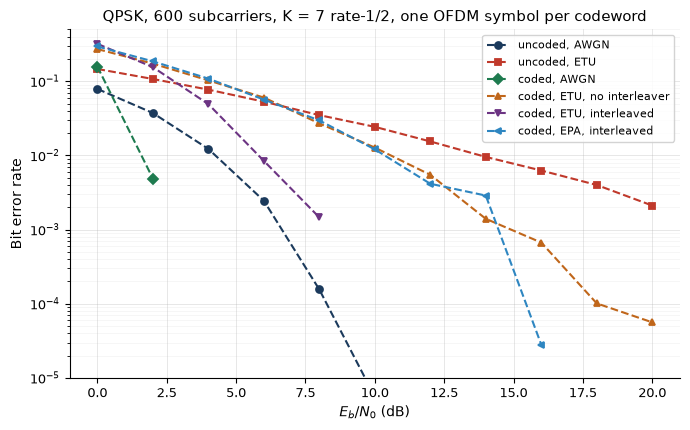

curve,BER at 6 dB,10 dB,14 dB
"uncoded, AWGN",2.4e-03,5.6e-06,0.0e+00
"uncoded, ETU",5.3e-02,2.4e-02,9.5e-03
"coded, AWGN",0.0e+00,0.0e+00,0.0e+00
"coded, ETU, no interleaver",6.0e-02,1.3e-02,1.4e-03
"coded, ETU, interleaved",8.4e-03,0.0e+00,0.0e+00
"coded, EPA, interleaved",5.7e-02,1.2e-02,2.9e-03


In [11]:
code = cl.ConvCode()
ninfo = Nu - (code.K - 1)
perm = rng.permutation(2 * Nu)
def coded_ber(profile, ebn0, coded, inter, B=100, nblk=3):
    errs = tot = 0
    esn0 = ebn0 + lk.db(2 * (ninfo / (2 * Nu) if coded else 1))
    n0 = lk.undb(-esn0)
    for _ in range(nblk):
        H = np.ones((B, Nu), complex) if profile == "AWGN" else oa.tdl_freq_response(profile, k, N, oa.FS_LTE, rng, n_draws=B)
        if coded:
            u = rng.integers(0, 2, (B, ninfo)); c = code.encode_batch(u); ci = c[:, perm] if inter else c
        else:
            ci = rng.integers(0, 2, (B, 2 * Nu))
        s = QPSK.modulate(ci.ravel()).reshape(B, Nu)
        y = H * s + np.sqrt(n0 / 2) * (rng.standard_normal((B, Nu)) + 1j * rng.standard_normal((B, Nu)))
        llr = QPSK.llr(y.ravel(), n0, h=H.ravel()).reshape(B, 2 * Nu)
        if coded:
            if inter:
                l2 = np.empty_like(llr); l2[:, perm] = llr; llr = l2
            errs += np.sum(code.decode_batch(llr) != u); tot += u.size
        else:
            errs += np.sum((llr < 0) != ci); tot += ci.size
    return errs / tot
eb = np.arange(0, 21, 2)
curves = [("uncoded, AWGN", "AWGN", False, False), ("uncoded, ETU", "ETU", False, False), ("coded, AWGN", "AWGN", True, False),
          ("coded, ETU, no interleaver", "ETU", True, False), ("coded, ETU, interleaved", "ETU", True, True),
          ("coded, EPA, interleaved", "EPA", True, True)]
sims = {}
for lab, prof, cd, it_ in curves:
    v = []
    for e in eb:
        b_ = coded_ber(prof, e, cd, it_) if (not v or v[-1] > 2e-6) else 0.0
        v.append(b_)
    sims[lab] = v
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb, sims=sims, ylim=(1e-5, 0.5))
ax.set_title("QPSK, 600 subcarriers, K = 7 rate-1/2, one OFDM symbol per codeword")
lk.show(f)
lk.table([[lab] + [f"{v[i]:.1e}" for i in (3, 5, 7)] for lab, v in sims.items()], ["curve", "BER at 6 dB", "10 dB", "14 dB"])

**What you should see.** Uncoded ETU is the Rayleigh curve (about $10^{-2}$ at 14 dB). Coding without interleaving helps a little; with the bit
interleaver the ETU curve plunges almost like AWGN, a few dB to the right of it: the code sees hundreds of independent subcarrier fades.
EPA's short delay spread gives fewer independent fades per codeword, so its curve falls more slowly than ETU's. This is coded OFDM (COFDM),
the reason DAB, DVB-T, Wi-Fi and LTE all interleave across frequency.

## 4. PAPR, clipping and filtering, and the power amplifier

OFDM's envelope is nearly Gaussian, so its PAPR at $10^{-3}$ is about 10–11 dB. A power amplifier must back off accordingly, and back-off is
expensive (Chapter 17's worked example: 10 dB of back-off drops a class-B PA from 78.5% to 25% efficiency). **Clipping and filtering**
limits the peaks and then removes the out-of-band splatter; repeating it a few times lowers the PAPR further at the cost of in-band EVM. The
real test is through a PA: below, a Rapp PA ($p = 2$) at an adjustable output back-off, with and without crest-factor reduction (CFR), and
the resulting EVM and adjacent-channel leakage ratio (ACLR).

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

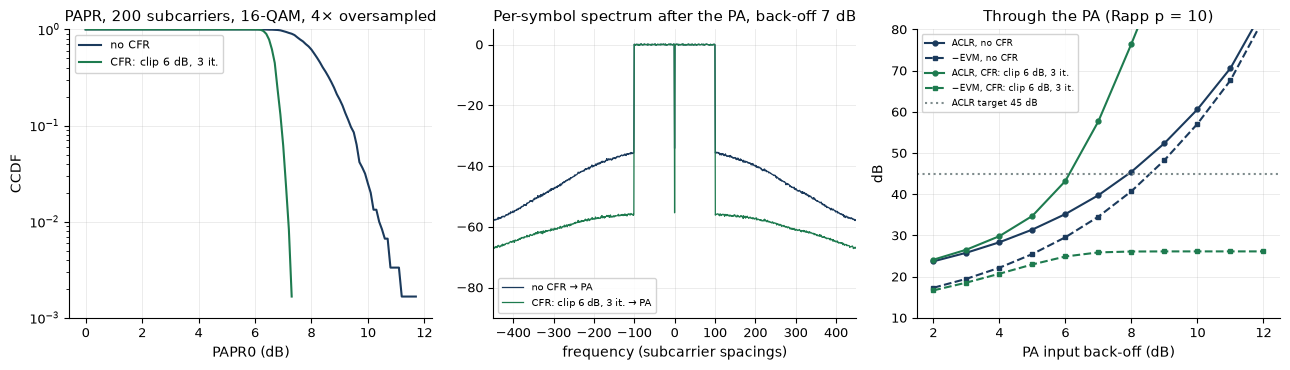

signal,PAPR at 1e-3 (dB),EVM after CFR alone (dB),EVM after PA (dB),ACLR after PA (dB)
no CFR,11.7,—,-34.6,39.8
"CFR: clip 6 dB, 3 it.",7.3,-26.1,-25.9,57.7


back-off (dB),class-B efficiency (%),DC power for 40 W out (W),heat (W)
0,78,51,11
6,39,102,62
10,25,161,121


In [13]:
L_os, nf_, nu_ = 4, 256, 200
cfg_c = co.OFDMConfig(L_os * nf_, nu_, 0)
nsym = 600
gc = qam(Q16, nu_ * nsym).reshape(nsym, nu_)
xc = co.ofdm_modulate(gc, cfg_c).reshape(nsym, -1)

def pa_demo(clip_db=6.0, iters=3, ibo_db=7.0, smooth=10.0):
    variants = {"no CFR": xc, f"CFR: clip {clip_db:g} dB, {iters} it.": oa.clip_filter(xc, cfg_c, clip_db, iters)}
    pa = lambda y, b: cl.rapp_pa(y.ravel() / np.sqrt(np.mean(np.abs(y) ** 2)), sat=10 ** (b / 20), p=smooth).reshape(y.shape)         * np.sqrt(np.mean(np.abs(y) ** 2))
    grid = np.linspace(0, 12, 121)
    f, ax = lk.fig((13, 3.8), 1, 3)
    rows = []
    for (lab, y), col in zip(variants.items(), [lk.NAVY, lk.GREEN]):
        gg, cc = co.ccdf(co.papr_db(y.ravel(), L_os * nf_), grid)
        ax[0].semilogy(gg, np.where(cc > 0, cc, np.nan), color=col, label=lab)
        z = pa(y, ibo_db)
        P = np.fft.fftshift(np.mean(np.abs(np.fft.fft(z, axis=1)) ** 2, axis=0))
        fb = np.arange(-L_os * nf_ // 2, L_os * nf_ // 2)
        ax[1].plot(fb, lk.db(P / np.median(P[np.abs(fb) < 60])), color=col, lw=0.9, label=f"{lab} → PA")
        papr3 = float(np.interp(-3, np.log10(np.maximum(cc[::-1], 1e-9)), gg[::-1]))
        ev_cfr = "—" if lab == "no CFR" else f"{oa.bussgang_evm_db(y, gc, cfg_c, gc):.1f}"
        rows.append([lab, papr3, ev_cfr, oa.bussgang_evm_db(z, gc, cfg_c, gc), oa.aclr_symbols(z, cfg_c)])
    ax[0].set_ylim(1e-3, 1); ax[0].set_xlabel("PAPR0 (dB)"); ax[0].set_ylabel("CCDF"); ax[0].legend(fontsize=8)
    ax[0].set_title("PAPR, 200 subcarriers, 16-QAM, 4× oversampled")
    ax[1].set_xlim(-450, 450); ax[1].set_ylim(-90, 5); ax[1].set_xlabel("frequency (subcarrier spacings)"); ax[1].legend(fontsize=7.5)
    ax[1].set_title(f"Per-symbol spectrum after the PA, back-off {ibo_db:g} dB")
    ibos = np.arange(2, 12.1, 1.0)
    for (lab, y), col in zip(variants.items(), [lk.NAVY, lk.GREEN]):
        zs = [pa(y, b) for b in ibos]
        ax[2].plot(ibos, [oa.aclr_symbols(z, cfg_c) for z in zs], "o-", color=col, ms=3.5, label=f"ACLR, {lab}")
        ax[2].plot(ibos, [-oa.bussgang_evm_db(z, gc, cfg_c, gc) for z in zs], "s--", color=col, ms=3.5, label=f"−EVM, {lab}")
    ax[2].axhline(45, color=lk.GRAY, ls=":", label="ACLR target 45 dB")
    ax[2].set_xlabel("PA input back-off (dB)"); ax[2].set_ylabel("dB"); ax[2].set_ylim(10, 80); ax[2].legend(fontsize=6.8)
    ax[2].set_title(f"Through the PA (Rapp p = {smooth:g})")
    lk.show(f)
    lk.table(rows, ["signal", "PAPR at 1e-3 (dB)", "EVM after CFR alone (dB)", "EVM after PA (dB)", "ACLR after PA (dB)"], fmt=".1f")

lk.interact(pa_demo, clip_db=lk.slider(6, 2, 9, 0.5, "clipping level above RMS (dB)"), iters=lk.islider(3, 1, 8, 1, "clip-filter iterations"),
            ibo_db=lk.slider(7, 0, 12, 0.5, "PA input back-off (dB)"),
            smooth=lk.choice([2.0, 3.0, 10.0], 10.0, "PA smoothness p (10 ≈ linearised by DPD)"))
eta = lambda bo: 0.785 * 10 ** (-bo / 20)
lk.table([[bo, 100 * eta(bo), 40 / eta(bo), 40 / eta(bo) - 40] for bo in (0, 6, 10)],
         ["back-off (dB)", "class-B efficiency (%)", "DC power for 40 W out (W)", "heat (W)"], fmt=".0f",
         title="Chapter 17: what back-off costs (ideal class B)")

**What you should see.** CFR cuts the PAPR at $10^{-3}$ from about 11.7 dB to roughly 7.3 dB, at the price of an in-band EVM of about −26 dB
that it introduces itself. The PA here is a Rapp model with $p = 10$, close to an ideal limiter, which is what a PA linearised by digital
predistortion looks like. At 7 dB back-off the original signal's peaks hit the limit uncontrolled and splatter into the neighbouring channel
(ACLR about 40 dB), while the CFR signal stays inside the limit and keeps an ACLR near 58 dB. CFR trades in-band EVM, which the link budget can
afford, for out-of-band emission, which the regulator does not tolerate, and so lets the PA run several dB closer to saturation. With a soft
PA ($p = 2$) the benefit shrinks: the amplifier compresses everything gradually anyway. The efficiency table shows what each dB of back-off is worth.

### Try it yourself 4.1
What is the ideal class-B efficiency (%) at 8 dB of back-off?

In [15]:
answer_4_1 = None
lk.check("4.1 class-B efficiency at 8 dB back-off (%)", answer_4_1, 100 * eta(8), atol=0.5)

[TODO] 4.1 class-B efficiency at 8 dB back-off (%): not attempted yet: replace the None with your answer

## 5. Spectral containment: WOLA and filtered OFDM

Each OFDM symbol is a rectangular-windowed burst of sinusoids, so its sidelobes decay only as $1/f$. Two fixes are used in 5G NR transmitters
(the standard leaves the method open): **WOLA** tapers the symbol edges with a short raised-cosine ramp inside an extended cyclic prefix, and
**filtered OFDM** passes the whole waveform through a sharp digital low-pass filter whose length is a fraction of a symbol. Setting: LTE 10 MHz
(600 subcarriers, 9 MHz occupied), 4× oversampled.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

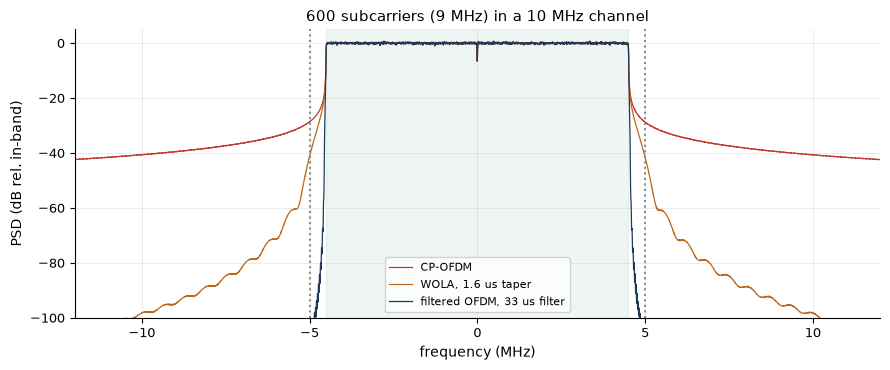

waveform,"ACLR, adjacent 10 MHz channel (dB; 100 = measurement floor)"
CP-OFDM,38.6
"WOLA, 1.6 us taper",76.2
"filtered OFDM, 33 us filter",100.0


In [17]:
def oob_demo(wola_us=1.6, filt_us=33.0):
    Lx, nsym_ = 4, 300
    fs = oa.FS_LTE * Lx
    gg = qam(Q16, Nu * nsym_).reshape(nsym_, Nu)
    c4 = co.OFDMConfig(N * Lx, Nu, 72 * Lx)
    x_cp = co.ofdm_modulate(gg, c4)
    W = max(2, int(round(wola_us * 1e-6 * fs)))
    x_w = oa.wola_ofdm(gg, N * Lx, 72 * Lx, W)
    ntap = int(round(filt_us * 1e-6 * fs)) | 1
    x_f = oa.filtered_ofdm(x_cp, fs, (Nu + 4) * 15e3, ntap)
    f, ax = lk.fig((9, 3.8))
    rows = []
    for lab, y, col in [("CP-OFDM", x_cp, lk.RED), (f"WOLA, {wola_us:g} us taper", x_w, lk.ORANGE), (f"filtered OFDM, {filt_us:g} us filter", x_f, lk.NAVY)]:
        fr, p = oa.psd(y, fs, 8192)
        ax.plot(fr / 1e6, lk.db(p / np.median(p[np.abs(fr) < 3e6]) + 1e-15), color=col, lw=0.9, label=lab)
        rows.append([lab, min(oa.aclr_db(y, fs, 9e6, 10e6, 9e6, 8192), 100.0)])
    ax.axvspan(-4.5, 4.5, color=lk.GREEN, alpha=0.07)
    for v in (-5, 5):
        ax.axvline(v, color=lk.GRAY, ls=":")
    ax.set_xlim(-12, 12); ax.set_ylim(-100, 5); ax.set_xlabel("frequency (MHz)"); ax.set_ylabel("PSD (dB rel. in-band)")
    ax.legend(fontsize=8, loc="lower center"); ax.set_title("600 subcarriers (9 MHz) in a 10 MHz channel")
    lk.show(f)
    lk.table(rows, ["waveform", "ACLR, adjacent 10 MHz channel (dB; 100 = measurement floor)"], fmt=".1f")

lk.interact(oob_demo, wola_us=lk.slider(1.6, 0.2, 4.0, 0.1, "WOLA taper (us)"), filt_us=lk.slider(33, 4, 66, 1, "filter length (us)"))

**What you should see.** Plain CP-OFDM's spectrum falls slowly outside the 9 MHz occupied band (an ACLR of about 39 dB, mostly from the near
edge of the adjacent channel); a 1.6 µs WOLA taper pushes the ACLR to about 75 dB, and a 33 µs filter (half a symbol) produces a near brick-wall
edge whose leakage is below what this measurement can resolve. (These are ideal digital numbers: a real PA's regrowth, Section 4, usually dominates.) The price is a little ISI (WOLA eats into the CP; the filter's
transient spreads into it), which the CP was sized to absorb. Shorten the filter: containment degrades quickly below about 10 µs.

## 6. DMT on copper: bit loading and reach

DSL's DMT is OFDM on a wire, where the channel barely changes, so the transmitter can load each tone with exactly the bits its SNR supports:
$b_k=\lfloor\log_2(1+\mathrm{SNR}_k/\Gamma)\rfloor$, with $\Gamma = 9.8 + 6 - 4 = 11.8$ dB (uncoded gap + margin − coding gain), up to 15 bits,
4000 DMT symbols per second. Chapter 17's ADSL2+ example: about 5.6 Mb/s on 3 km, 27 Mb/s on 1 km, 1 Mb/s on 5 km.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

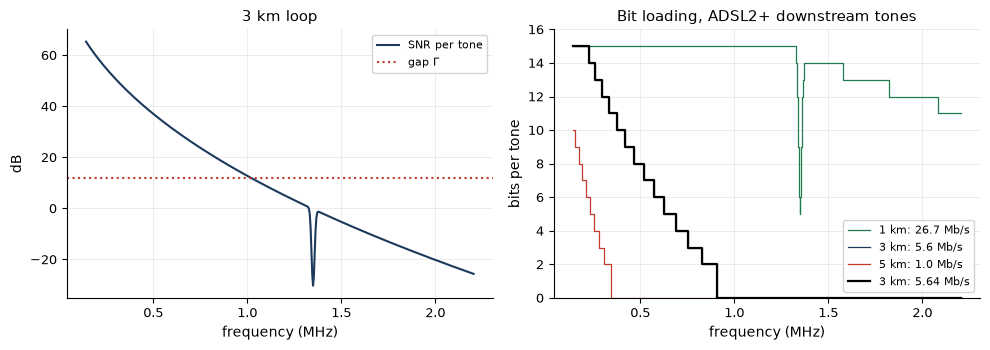

,
bits per DMT symbol,1410
line rate (Mb/s),5.64
water-filling capacity with the gap (Mb/s),7.18
flat-PSD capacity with the gap (Mb/s),6.35


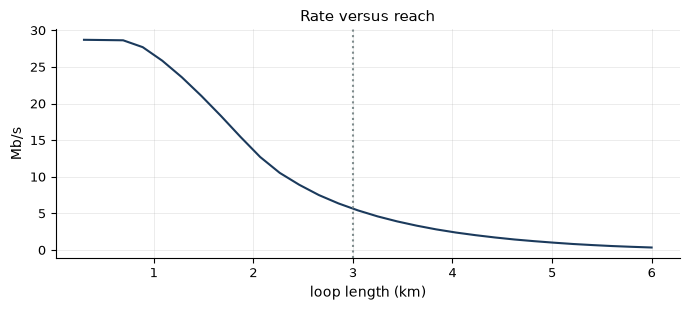

In [19]:
tones = np.arange(33, 512)
fdmt = tones * 4312.5

def dmt_demo(loop_km=3.0, gap_db=11.8, rfi_db=30.0):
    snr = oa.dsl_snr_db(fdmt, loop_km, rfi_db=rfi_db)
    b = oa.dmt_bit_loading(snr, gap_db)
    s = lk.undb(snr - gap_db)
    pw, mu = oa.waterfill_bisect(1 / s, len(tones) * 1.0)
    f, ax = lk.fig("row2", 1, 2)
    ax[0].plot(fdmt / 1e6, snr, color=lk.NAVY, label="SNR per tone"); ax[0].axhline(gap_db, color=lk.RED, ls=":", label="gap Γ")
    ax[0].set_xlabel("frequency (MHz)"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8); ax[0].set_title(f"{loop_km:g} km loop")
    for L, col in [(1, lk.GREEN), (3, lk.NAVY), (5, lk.RED)]:
        bb = oa.dmt_bit_loading(oa.dsl_snr_db(fdmt, L, rfi_db=rfi_db), gap_db)
        ax[1].step(fdmt / 1e6, bb, where="mid", color=col, lw=0.9, label=f"{L} km: {4000 * bb.sum() / 1e6:.1f} Mb/s")
    ax[1].step(fdmt / 1e6, b, where="mid", color="k", lw=1.6, label=f"{loop_km:g} km: {4000 * b.sum() / 1e6:.2f} Mb/s")
    ax[1].set_xlabel("frequency (MHz)"); ax[1].set_ylabel("bits per tone"); ax[1].set_ylim(0, 16); ax[1].legend(fontsize=8)
    ax[1].set_title("Bit loading, ADSL2+ downstream tones")
    lk.show(f)
    lk.table([["bits per DMT symbol", int(b.sum())], ["line rate (Mb/s)", 4000 * b.sum() / 1e6],
              ["water-filling capacity with the gap (Mb/s)", 4000 * np.sum(np.log2(1 + pw * s)) / 1e6],
              ["flat-PSD capacity with the gap (Mb/s)", 4000 * np.sum(np.log2(1 + s)) / 1e6]], ["", ""], fmt=".2f")
    Ls = np.linspace(0.3, 6, 30)
    f, ax = lk.fig((7, 3.2))
    ax.plot(Ls, [4000 * oa.dmt_bit_loading(oa.dsl_snr_db(fdmt, L_, rfi_db=rfi_db), gap_db).sum() / 1e6 for L_ in Ls], color=lk.NAVY)
    ax.axvline(loop_km, color=lk.GRAY, ls=":"); ax.set_xlabel("loop length (km)"); ax.set_ylabel("Mb/s"); ax.set_title("Rate versus reach")
    lk.show(f)

lk.interact(dmt_demo, loop_km=lk.slider(3.0, 0.3, 6.0, 0.1, "loop length (km)"), gap_db=lk.slider(11.8, 6, 18, 0.2, "gap Γ (dB)"),
            rfi_db=lk.slider(30, 0, 50, 1, "AM ingress (dB)"))

**What you should see.** 5.6 Mb/s at 3 km, 26.7 at 1 km and 1.0 at 5 km, as in the chapter, with the AM ingress notch visible in the loading.
Water-filling would add about 13% at 3 km (it moves power from hopeless high tones to marginal ones), but DSL transmitters must respect a fixed
regulatory PSD mask, so bit loading is the only adaptation used. The rate-versus-reach curve is the economic story of DSL and the reason fibre
moved ever closer to the home (Chapter 24).

### Try it yourself 6.1
What line rate (Mb/s) does the model give on a 2 km loop with the default gap?

In [21]:
answer_6_1 = None
lk.check("6.1 ADSL2+ rate on 2 km (Mb/s)", answer_6_1, 4000 * oa.dmt_bit_loading(oa.dsl_snr_db(fdmt, 2.0)).sum() / 1e6, atol=0.1)

[TODO] 6.1 ADSL2+ rate on 2 km (Mb/s): not attempted yet: replace the None with your answer

## 7. OFDM as a radar

Transmit a known OFDM grid, receive its echo: dividing out the data leaves $e^{-j2\pi m\Delta f\,2R/c}\,e^{j2\pi n T_{\text{sym}}\,2vf_c/c}$ for each target.
An IFFT across subcarriers resolves **range** ($\Delta R = c/(2M\Delta f)$, the bandwidth) and an FFT across symbols resolves **velocity**
($\Delta v = c/(2f_cNT_{\text{sym}})$, the dwell time). This is the integrated sensing and communication (ISAC) idea of Chapter 25, in two FFTs.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

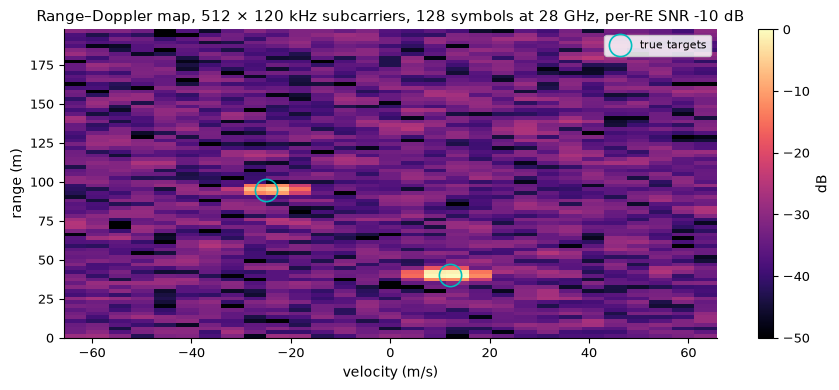

,
range resolution,2.44 m
max unambiguous range,1250 m
velocity resolution,4.69 m/s
max unambiguous velocity,±300 m/s
processing gain M·N,48.2 dB


In [23]:
def radar_demo(r1=40.0, v1=12.0, r2=95.0, v2=-25.0, snr_db=-10.0, scs_khz=120.0):
    M, Ns, fc = 512, 128, 28e9
    df = scs_khz * 1e3
    Tsym = 1 / df * (1 + 0.07)                                   # with a ~7% CP
    X = QPSK.points[rng.integers(0, 4, (M, Ns))]
    Y = oa.radar_echo(X, [(r1, v1, 1.0), (r2, v2, 0.5)], df, Tsym, fc, n0=lk.undb(-snr_db), rng=rng)
    P = oa.radar_map(Y, X)
    dR, dv = 3e8 / (2 * M * df), 3e8 / (2 * fc * Ns * Tsym)
    rr = np.arange(M) * dR; vv = (np.arange(Ns) - Ns // 2) * dv
    sel = rr < 200
    vs = np.abs(vv) <= 70
    f, ax = lk.fig((9, 4.0))
    im = ax.imshow(lk.db(P[sel][:, vs] / P.max()), aspect="auto", origin="lower", extent=[vv[vs][0], vv[vs][-1], 0, rr[sel][-1]],
                   vmin=-50, vmax=0, cmap="magma", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="dB"); ax.grid(False)
    ax.plot([v1, v2], [r1, r2], "o", mfc="none", mec="c", ms=16, mew=1.2, label="true targets")
    ax.set_xlabel("velocity (m/s)"); ax.set_ylabel("range (m)"); ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"Range–Doppler map, {M} × {scs_khz:g} kHz subcarriers, {Ns} symbols at 28 GHz, per-RE SNR {snr_db:g} dB")
    lk.show(f)
    lk.table([["range resolution", f"{dR:.2f} m"], ["max unambiguous range", f"{M * dR:.0f} m"], ["velocity resolution", f"{dv:.2f} m/s"],
              ["max unambiguous velocity", f"±{Ns / 2 * dv:.0f} m/s"], ["processing gain M·N", f"{lk.db(M * Ns):.1f} dB"]], ["", ""])

lk.interact(radar_demo, r1=lk.slider(40, 5, 190, 1, "target 1 range (m)"), v1=lk.slider(12, -60, 60, 1, "target 1 velocity (m/s)"),
            r2=lk.slider(95, 5, 190, 1, "target 2 range (m)"), v2=lk.slider(-25, -60, 60, 1, "target 2 velocity (m/s)"),
            snr_db=lk.slider(-10, -40, 20, 1, "per-RE SNR (dB)"), scs_khz=lk.choice([30.0, 60.0, 120.0, 240.0], 120.0, "subcarrier spacing (kHz)"))

**What you should see.** Two sharp peaks at the right ranges and velocities even at −10 dB SNR per resource element: the map has $10\log_{10}(512\times128)
\approx 48$ dB of processing gain. With 120 kHz spacing the range resolution is about 2.4 m; the velocity resolution is set by the 128-symbol dwell. Lower
the subcarrier spacing to 30 kHz: range resolution coarsens fourfold but the velocity resolution and unambiguous range improve, the same trade-off as
the numerology of Section 2 of Chapter 17.

### Try it yourself 7.1
What is the range resolution (m) of an OFDM radar using 3300 subcarriers at 30 kHz (a 100 MHz NR carrier)?

In [25]:
answer_7_1 = None
lk.check("7.1 range resolution, 3300 x 30 kHz (m)", answer_7_1, 299_792_458 / (2 * 3300 * 30e3), atol=0.02)

[TODO] 7.1 range resolution, 3300 x 30 kHz (m): not attempted yet: replace the None with your answer

## Key takeaways
* Pilot spacing must sample the channel in frequency and time; LMMSE (or DFT-based) estimation buys several dB over linear interpolation.
* Frequency offset and Doppler create ICI ($\approx 3/(\pi\epsilon)^2$, $6/(\pi f_DT)^2$); phase noise adds a removable CPE and an irreducible ICI floor.
* Coding plus bit interleaving across subcarriers turns frequency-selective fading into diversity.
* OFDM's ~10 dB PAPR costs PA efficiency; clipping and filtering trades a little EVM for several dB of back-off and better ACLR through the PA.
* WOLA and filtered OFDM contain the 1/f sidelobes of rectangular symbols.
* On static wires, bit loading adapts every tone: DSL's rate falls steeply with loop length.
* The same grid is a radar: range from bandwidth, velocity from dwell.

## Going further (hardware: USRP B200 / GNU Radio)
* Run `gnuradio/gr04_ofdm_link.py --sim --multipath --cfo 5000` and log the channel estimates: compare their smoothness with the LS and LMMSE
  estimators of Section 1. Over the air through a 30 dB attenuator, sweep the TX gain and plot EVM against output power to find the B200's
  compression point, then add clipping-and-filtering in the transmitter (Section 4) and repeat.
* Capture an LTE downlink with the B200 and identify its 600-subcarrier occupied band and its spectral skirts against Section 5's curves.

## Exercises
1. **(Warm-up)** Show that the DFT estimator is exact for a sample-spaced channel whose taps all lie inside the delay window.
2. **(Core)** Add time-domain interpolation between pilot symbols (one DMRS every 7 symbols) at 120 km/h and measure the MSE penalty versus the
   Doppler (Chapter 17's pilot-density example).
3. **(Core)** Replace QPSK in Section 3 with Gray 16-QAM BICM and compare the ETU gain over uncoded transmission.
4. **(Stretch)** Add a Saleh TWTA (`commlib.satellite.saleh_twta`) and digital predistortion to Section 4 and plot ACLR versus output back-off.

In [27]:
lk.summary()

[good] Lab 28 finished in 24.5 s. Self-checks: 0 passed, 0 failed, 5 still to do.